In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Parse to `timestamp_start` and `timestamp_end` of trucks

In [3]:
df_truck_only = pd.read_csv('data/transformed_truck_activities_log.csv', parse_dates=['timestamp', 'timestamp_end'])
df_contingencies = pd.read_csv('data/remapped_contingencies_log.csv', parse_dates=['timestamp', 'timestamp_end'])

In [4]:
print(df_contingencies.columns.tolist())
print(df_truck_only.columns.tolist())

['case_id', 'activity', 'timestamp', 'timestamp_end', 'timediff', 'shiftid']
['case_id', 'activity', 'timestamp', 'dumplocation', 'cycle_iteration', 'loadlocation', 'loadlocationunit', 'dumplocationunit', 'resource', 'excav', 'shiftname', 'crew', 'cycle_key', 'timestamp_end']


In [5]:
cols_to_keep_contingencies = ['case_id', 'activity', 'timestamp', 'timestamp_end']
cols_to_keep_truck = ['case_id', 'activity', 'timestamp', 'timestamp_end']
df_formed_contingencies = df_contingencies[cols_to_keep_contingencies]
df_formed_trucks = df_truck_only[cols_to_keep_truck]

In [6]:
from datetime import datetime
def print_time_range(df_log: pd.DataFrame) -> None:
  print(f'Starts on {df_log['timestamp'].min()} - ends on {df_log['timestamp_end'].max()}')

def find_valid_datetime_range(df_1: pd.DataFrame, df_2: pd.DataFrame) -> tuple[datetime, datetime]:
  """
    Find the common window time that both datasets have information
  """
  low_threshold_datetime = max(df_1['timestamp'].min(), df_2['timestamp'].min())
  high_threshold_datetime = min(df_1['timestamp_end'].max(), df_2['timestamp_end'].max())
  return pd.to_datetime(low_threshold_datetime), pd.to_datetime(high_threshold_datetime)

print('Contingencies')
print_time_range(df_formed_contingencies)
print('-' * 60)
print('Trucks')
print_time_range(df_formed_trucks)
start_date, end_date = find_valid_datetime_range(df_formed_contingencies, df_formed_trucks)

Contingencies
Starts on 2024-02-27 14:00:47 - ends on 2024-03-26 11:59:48
------------------------------------------------------------
Trucks
Starts on 2024-02-25 11:07:29.200000 - ends on 2024-03-26 08:46:07


In [7]:
df_log = pd.concat([df_formed_trucks, df_formed_contingencies])
df_log = df_log[df_log['timestamp'] >= start_date.to_datetime64()]
df_log = df_log[df_log['timestamp_end'] <= end_date.to_datetime64()]
df_log = df_log[df_log['activity'] != 'Efectivo']
df_log = df_log.sort_values(by=['case_id', 'timestamp', 'timestamp_end'])

In [8]:
def squeeze_consecutive_activities(df: pd.DataFrame) -> pd.DataFrame:
  df_not_repeated_log = df.copy()
  df_not_repeated_log['grouped_consecutives'] = (df_not_repeated_log['activity'] != df_not_repeated_log['activity'].shift()).cumsum()
  df_not_repeated_log['group_sum'] = df_not_repeated_log.groupby(by='grouped_consecutives').cumcount() + 1
  df_not_repeated_log.drop(columns=['grouped_consecutives']);
  total_rows = df_not_repeated_log.shape[0]
  df_not_repeated_log = df_not_repeated_log[df_not_repeated_log['group_sum'] == 1]
  filtered_rows = df_not_repeated_log.shape[0]
  print(f'Filtered a total of {total_rows - filtered_rows} rows')
  return df_not_repeated_log[df.columns]

In [9]:
df_log = squeeze_consecutive_activities(df_log)
df_log.head(10)

Filtered a total of 4001 rows


,case_id,activity,timestamp,timestamp_end
277,CA100,Carga,2024-02-27 14:05:56.000,2024-02-27 14:07:51
278,CA100,Traslado a descarga,2024-02-27 14:07:51.000,2024-02-27 14:27:53
279,CA100,Descarga,2024-02-27 14:29:21.000,2024-02-27 14:30:14
280,CA100,Traslado a carga,2024-02-27 14:30:14.200,2024-02-27 14:56:13
281,CA100,Carga,2024-02-27 14:56:13.000,2024-02-27 14:58:31
282,CA100,Traslado a descarga,2024-02-27 14:58:31.000,2024-02-27 15:01:58
283,CA100,Descarga,2024-02-27 15:07:54.000,2024-02-27 15:08:47
284,CA100,Traslado a carga,2024-02-27 15:08:47.200,2024-02-27 15:12:40
285,CA100,Carga,2024-02-27 15:16:13.000,2024-02-27 15:18:36
286,CA100,Traslado a descarga,2024-02-27 15:18:36.000,2024-02-27 15:27:10


In [10]:
SAVE_LOG = False
if SAVE_LOG:
  df_log.to_csv('data/grouped_activities.csv', index=False)

In [11]:
import mpdfg

format_dictionary = {
    'case:concept:name': 'case_id',
    'concept:name': 'activity',
    'start_timestamp': 'timestamp',
    'time:timestamp': 'timestamp_end',
    'cost:total': '',
    'org:resource': '',
}
df_formatted_log = mpdfg.log_formatter(log=df_log, format=format_dictionary)

In [12]:
dfg, start_activities, end_activities = mpdfg.discover_multi_perspective_dfg(log=df_formatted_log, calculate_cost=False)

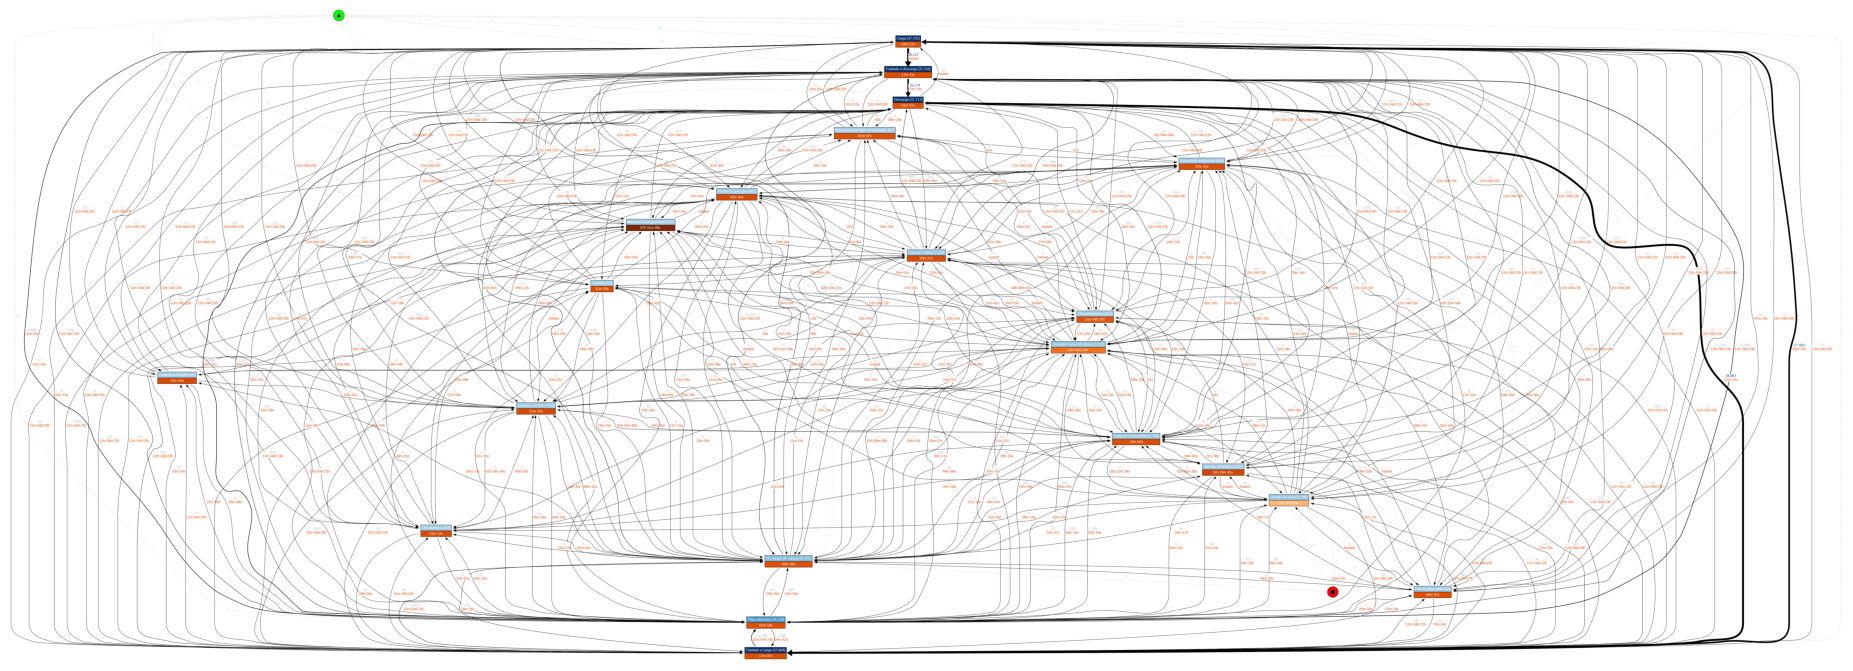

In [13]:
mpdfg.view_multi_perspective_dfg(dfg, start_activities, end_activities)

In [14]:
# Shape of the dfg:
# {'activities': Counter[str, itn], 'connections': Counter[tuple[str, str], dict[frequency, time]] }

connection_data = [{'origin': transition[0], 'destination': transition[1], **data} for transition, data in dfg['connections'].items()]
df_connections = pd.DataFrame(connection_data)

In [15]:
def filter_by_frequency(df_log: pd.DataFrame, percentile: float = 0.9) -> pd.DataFrame:
  return df_log[df_log['frequency'] > df_log['frequency'].quantile(percentile)]

def filter_between_frequency(df_log: pd.DataFrame, percentile_lower: float = 0, percentile_upper: float = 1) -> pd.DataFrame:
  return df_log[(df_log['frequency'] > df_log['frequency'].quantile(percentile_lower)) & 
                (df_log['frequency'] < df_log['frequency'].quantile(percentile_upper))]

In [16]:
def handle_negatives_times(df_connections: pd.DataFrame) -> pd.DataFrame:
  df_filter_connections_positive = df_connections[df_connections['time'] >= 0]
  df_filter_connections_negative = df_connections[df_connections['time'] < 0]
  # Swap the origin and destination for negative timestamps
  df_filter_connections_negative.columns = ['destination', 'origin', 'frequency', 'time']
  df_filter_connections_negative.loc[:,'time'] = df_filter_connections_negative['time'].abs()
  display(df_filter_connections_negative)
  df_sorted = pd.concat([df_filter_connections_negative, df_filter_connections_positive])
  df_sorted['total_time'] = df_sorted['frequency'] * df_sorted['time']
  print(f'Total before: {df_sorted.shape[0]}')
  df_resumed = df_sorted.groupby(['origin', 'destination']).agg({'frequency': 'sum', 'total_time': 'sum'})
  df_resumed['time'] = df_resumed['total_time'] / df_resumed['frequency']
  df_resumed = df_resumed.drop(columns=['total_time'])
  print(f'Total after:  {df_resumed.shape[0]}')
  return df_sorted

Is a list
Total rows 288. Filtered a total of 26 rows
['Pista obstruida' 'Traslado a carga' 'Sin equipo de carguio'
 'Traslado a descarga' 'Carga' 'Descarga']
{'Carga': 22, 'Pista obstruida': 11, 'Descarga': 7, 'Sin equipo de carguio': 3, 'Traslado a descarga': 2, 'Traslado a carga': 1} {'Descarga': 3, 'Sin equipo de carguio': 1}


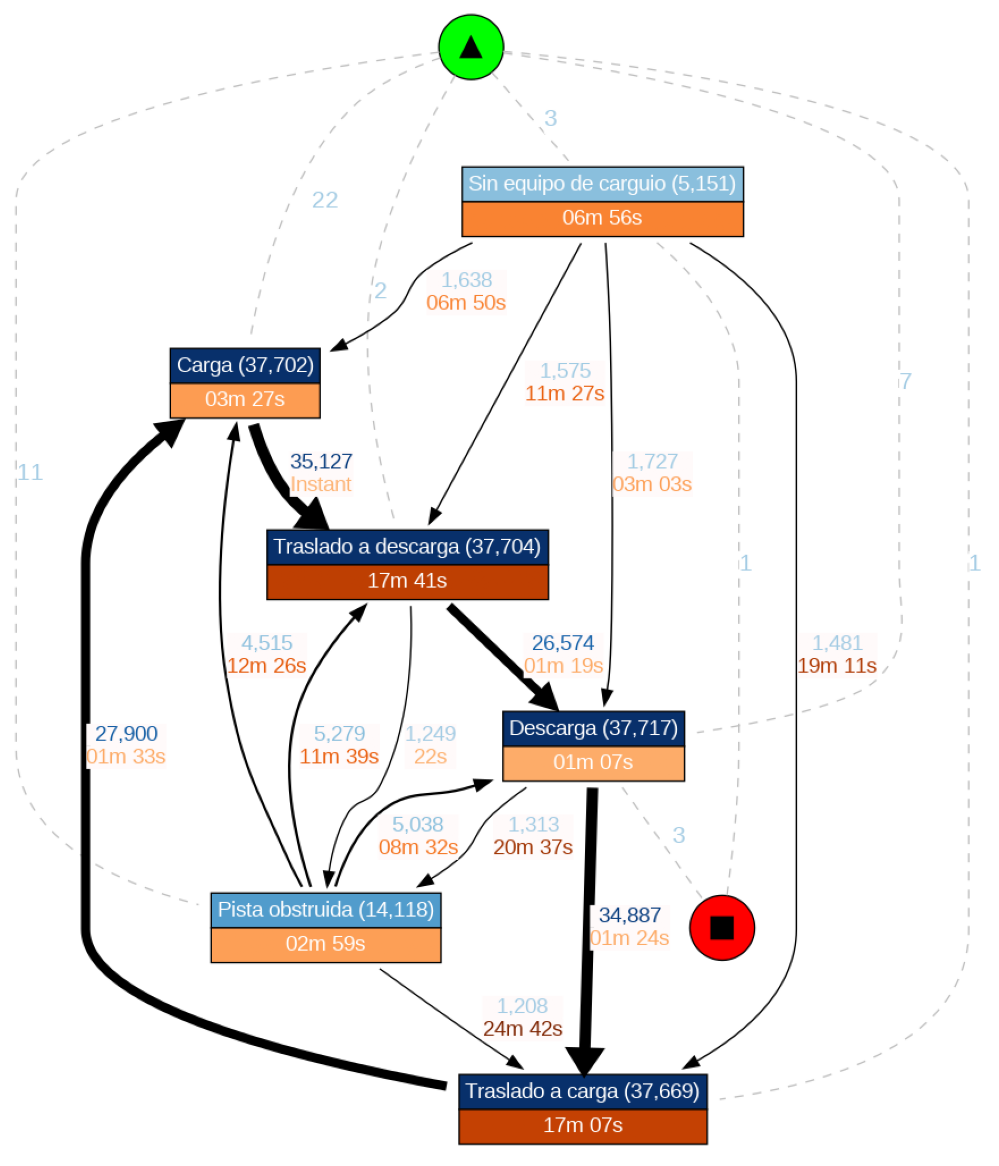

In [17]:
import numpy as np
from dfg_filtering import format_dfg_to_dataframe, handle_negatives_times,\
                          filter_by_percentile_frequency, generate_filtered_dfg_dict

def remove_not_connected_activities(dfg: dict) -> pd.DataFrame:
  dfg_copy = dfg.copy()
  unique_activities = pd.Series(sum([list(i) for i in dfg['connections'].keys()], [])).unique()
  print(unique_activities)
  dfg_copy['activities'] = { key: value for key, value in dfg['activities'].items() if key in unique_activities }
  return dfg_copy

def filter_start_and_end_activities(dfg, start_activities, end_activities) -> tuple[dict, dict]:
  unique_activities = pd.Series(sum([list(i) for i in dfg['connections'].keys()], [])).unique()
  return ({ key: value for key, value in start_activities.items() if key in unique_activities },
          { key: value for key, value in end_activities.items() if key in unique_activities })

def run_pipeline(dfg: dict, percentile: float, start_activities: dict, end_activities: dict) -> None:
  df_connections = format_dfg_to_dataframe(dfg)
  df_1 = handle_negatives_times(df_connections)
  df_2 = filter_by_percentile_frequency(df_1, percentile)
  dfg_connections_corrected = generate_filtered_dfg_dict(df_2)
  dfg_corrected = dfg.copy()
  dfg_corrected['connections'] = dfg_connections_corrected
  dfg_corrected = remove_not_connected_activities(dfg_corrected)
  start_activities, end_activities = filter_start_and_end_activities(dfg_corrected, start_activities, end_activities)
  print(start_activities, end_activities)
  mpdfg.view_multi_perspective_dfg(dfg_corrected, start_activities, end_activities)
  return dfg_corrected

dfg_result = run_pipeline(dfg, 0.95, start_activities, end_activities)

Is a list
Total rows 288. Filtered a total of 26 rows
['Pista obstruida' 'Traslado a carga' 'Sin equipo de carguio'
 'Traslado a descarga' 'Carga de combustible' 'Descarga' 'Cambio de turno'
 'Operador fuera del equipo' 'Carga' 'Colacion cabina']
{'Carga': 22, 'Pista obstruida': 11, 'Descarga': 7, 'Sin equipo de carguio': 3, 'Traslado a descarga': 2, 'Traslado a carga': 1, 'Operador fuera del equipo': 1} {'Cambio de turno': 27, 'Operador fuera del equipo': 16, 'Descarga': 3, 'Sin equipo de carguio': 1}


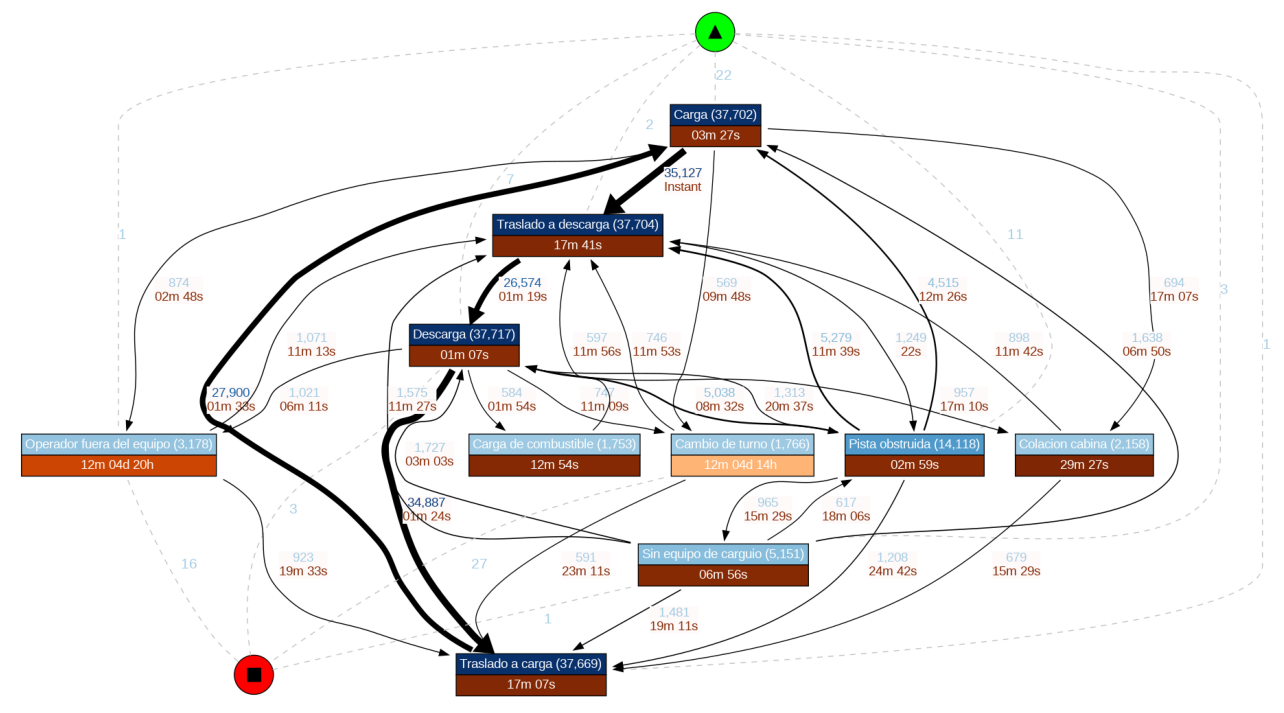

{'activities': {'Carga': {'frequency': 37702, 'time': 207.69},
  'Traslado a descarga': {'frequency': 37704, 'time': 1061.31},
  'Descarga': {'frequency': 37717, 'time': 67.45},
  'Traslado a carga': {'frequency': 37669, 'time': 1027.13},
  'Pista obstruida': {'frequency': 14118, 'time': 179.5},
  'Sin equipo de carguio': {'frequency': 5151, 'time': 416.74},
  'Carga de combustible': {'frequency': 1753, 'time': 774.82},
  'Cambio de turno': {'frequency': 1766, 'time': -35469.72},
  'Operador fuera del equipo': {'frequency': 3178, 'time': -11206.89},
  'Colacion cabina': {'frequency': 2158, 'time': 1767.11}},
 'connections': {('Pista obstruida', 'Traslado a carga'): {'frequency': 1208,
   'time': 1482.95},
  ('Sin equipo de carguio', 'Traslado a descarga'): {'frequency': 1575,
   'time': 687.78},
  ('Sin equipo de carguio', 'Traslado a carga'): {'frequency': 1481,
   'time': 1151.34},
  ('Carga de combustible', 'Traslado a descarga'): {'frequency': 597,
   'time': 716.77},
  ('Descarga'

In [18]:
run_pipeline(dfg, 0.90, start_activities, end_activities)

Is a list
Total rows 288. Filtered a total of 26 rows
['Pista obstruida' 'Traslado a carga' 'Sin equipo de carguio'
 'Traslado a descarga' 'Colacion comedor' 'Carga' 'Carga de combustible'
 'Descarga' 'Cambio de turno' 'Operador fuera del equipo'
 'Colacion cabina']
{'Carga': 22, 'Pista obstruida': 11, 'Descarga': 7, 'Sin equipo de carguio': 3, 'Traslado a descarga': 2, 'Traslado a carga': 1, 'Operador fuera del equipo': 1} {'Cambio de turno': 27, 'Operador fuera del equipo': 16, 'Descarga': 3, 'Sin equipo de carguio': 1}


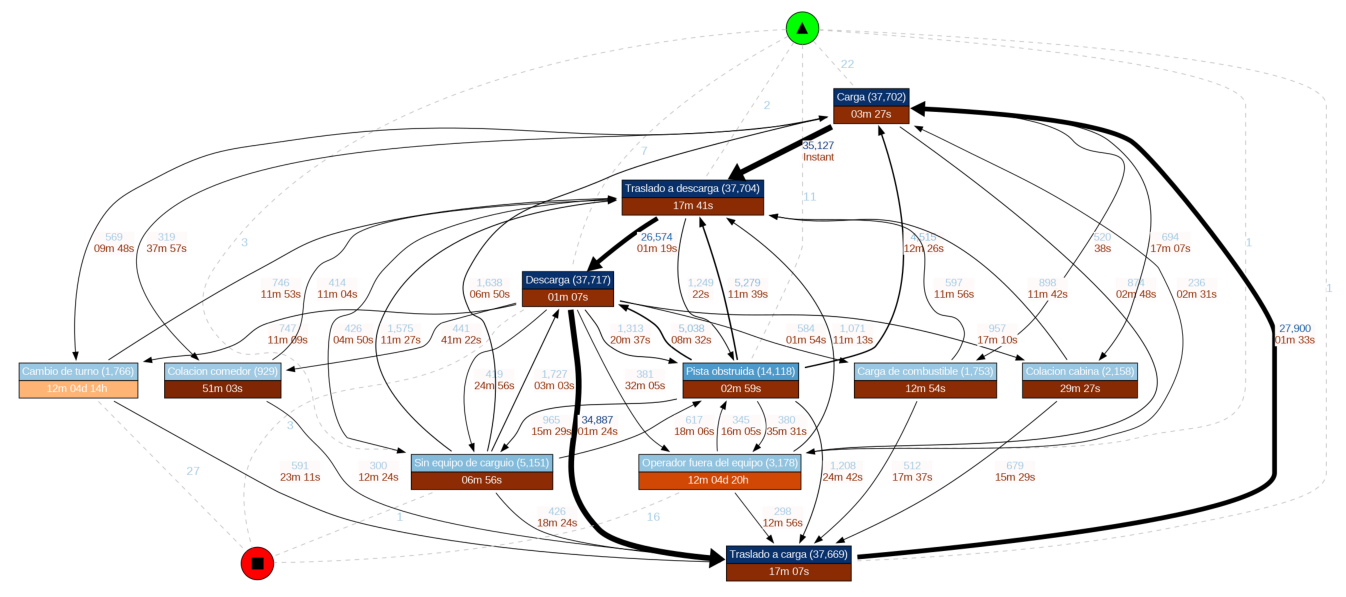

In [19]:
run_pipeline(dfg, 0.85, start_activities, end_activities);

Is a list
Total rows 288. Filtered a total of 26 rows
['Pista obstruida' 'Traslado a carga' 'Sin equipo de carguio'
 'Traslado a descarga' 'Colacion comedor' 'Carga' 'Carga de combustible'
 'Descarga' 'Cambio de turno' 'Operador fuera del equipo'
 'Colacion cabina' 'Problema operador' 'Mantencion imprevista']
{'Carga': 22, 'Pista obstruida': 11, 'Descarga': 7, 'Sin equipo de carguio': 3, 'Problema operador': 3, 'Traslado a descarga': 2, 'Mantencion imprevista': 1, 'Traslado a carga': 1, 'Operador fuera del equipo': 1} {'Cambio de turno': 27, 'Operador fuera del equipo': 16, 'Mantencion imprevista': 5, 'Descarga': 3, 'Sin equipo de carguio': 1}


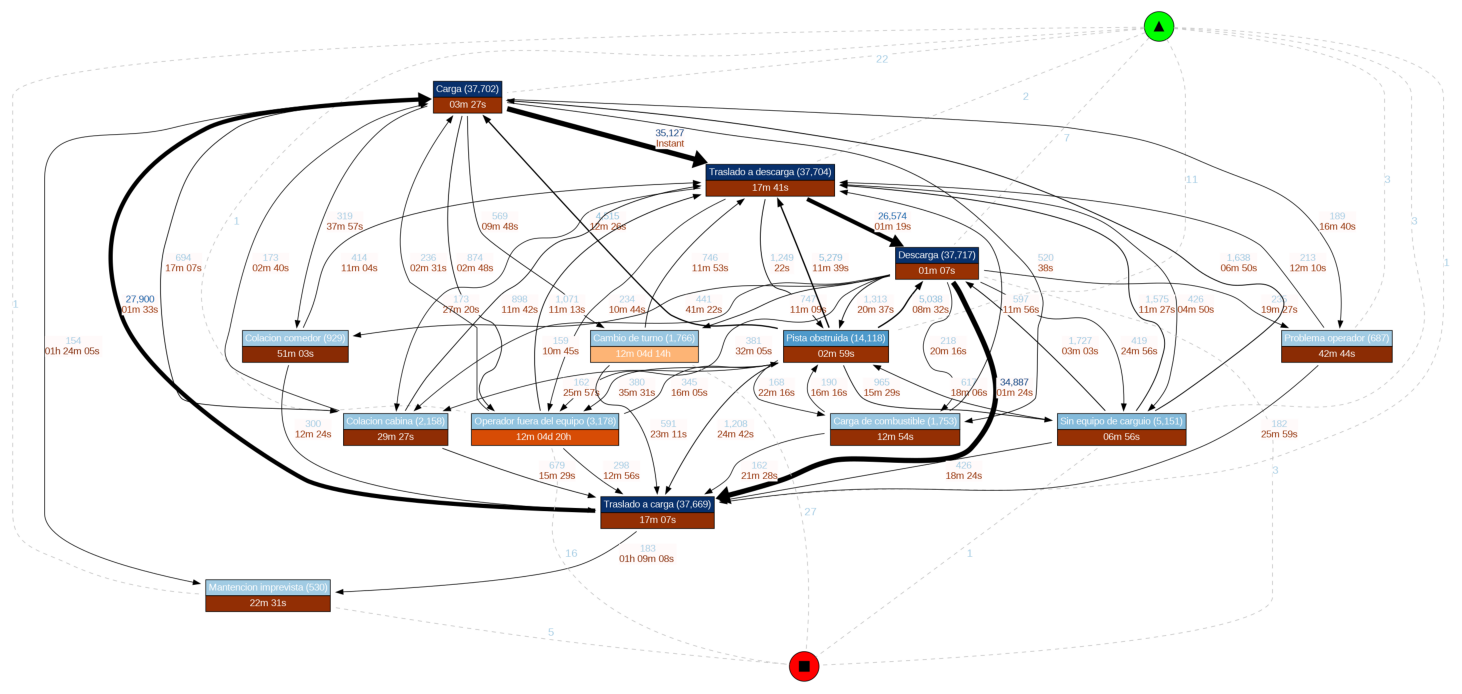

In [20]:
run_pipeline(dfg, 0.80, start_activities, end_activities);